In [19]:
# Importing important libraries
!mamba install pandas matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             recall_score, f1_score, accuracy_score)
print("✅ ALl libraries successfully imported!")


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.0543999999910594 seconds
All requested packages already installed.
✅ ALl libraries successfully imported!


In [4]:
# LOad Dataset
url = 'https://raw.githubusercontent.com/ndungek/Customer-Churn-Prediction/main/telecom.csv'
df = pd.read_csv(url)
print(f"✅ Dataset successfully loaded!")
print(f"Shape : {df.shape} →  {df.shape[0]} customers, {df.shape[1]} features")
df.head()

✅ Dataset successfully loaded!
Shape : (3333, 21) →  3333 customers, 21 features


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
# Dataset basic info
print("===Dataset Info===")
print(df.info())

===Dataset Info===
<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   str    
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   str    
 4   international plan      3333 non-null   str    
 5   voice mail plan         3333 non-null   str    
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non

In [6]:
# Finding missing values
print("===Missing Values===")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

===Missing Values===
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Total Missing Values: 0


churn
False    2850
True      483
Name: count, dtype: int64

Churn rate: 14.5%
Retained:   85.5%


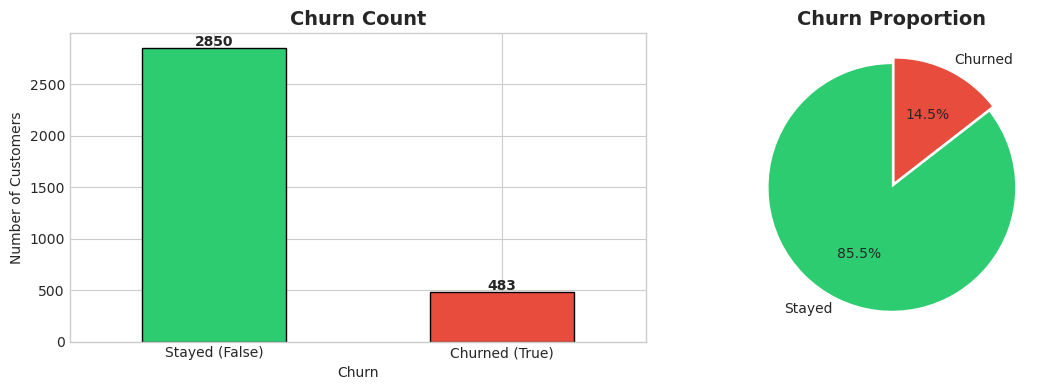


💡 Only 14.5% churn → Class Imbalance! We must use class_weight='balanced'


In [7]:
# Churn Distribution
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(f"\nChurn rate: {churn_pct[True]:.1f}%")
print(f"Retained:   {churn_pct[False]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#e74c3c']

churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['Stayed (False)', 'Churned (True)'], rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts, labels=['Stayed', 'Churned'],
            colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n💡 Only 14.5% churn → Class Imbalance! We must use class_weight='balanced'")

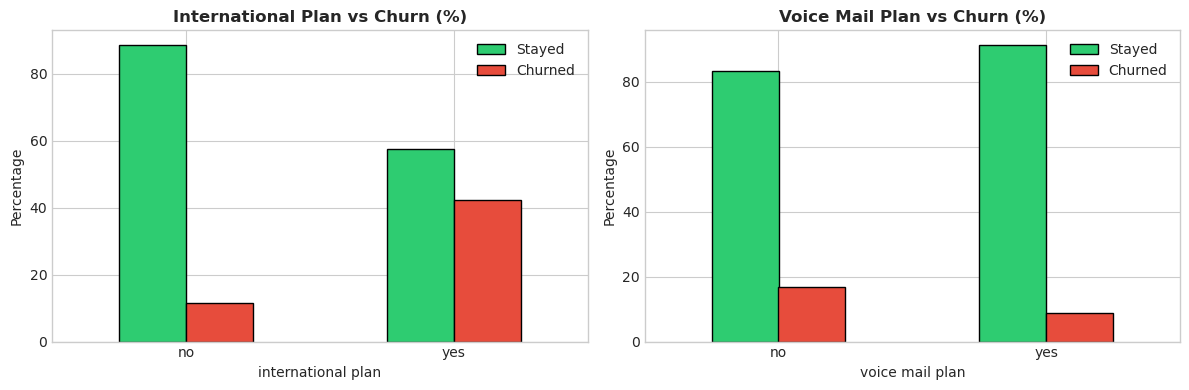

💡 International plan holders churn at ~42% — huge red flag!


In [8]:
# Categorical Features vs Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cat_cols = ['international plan', 'voice mail plan']

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'{col.title()} vs Churn (%)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')
    axes[i].legend(['Stayed', 'Churned'])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()
print("💡 International plan holders churn at ~42% — huge red flag!")

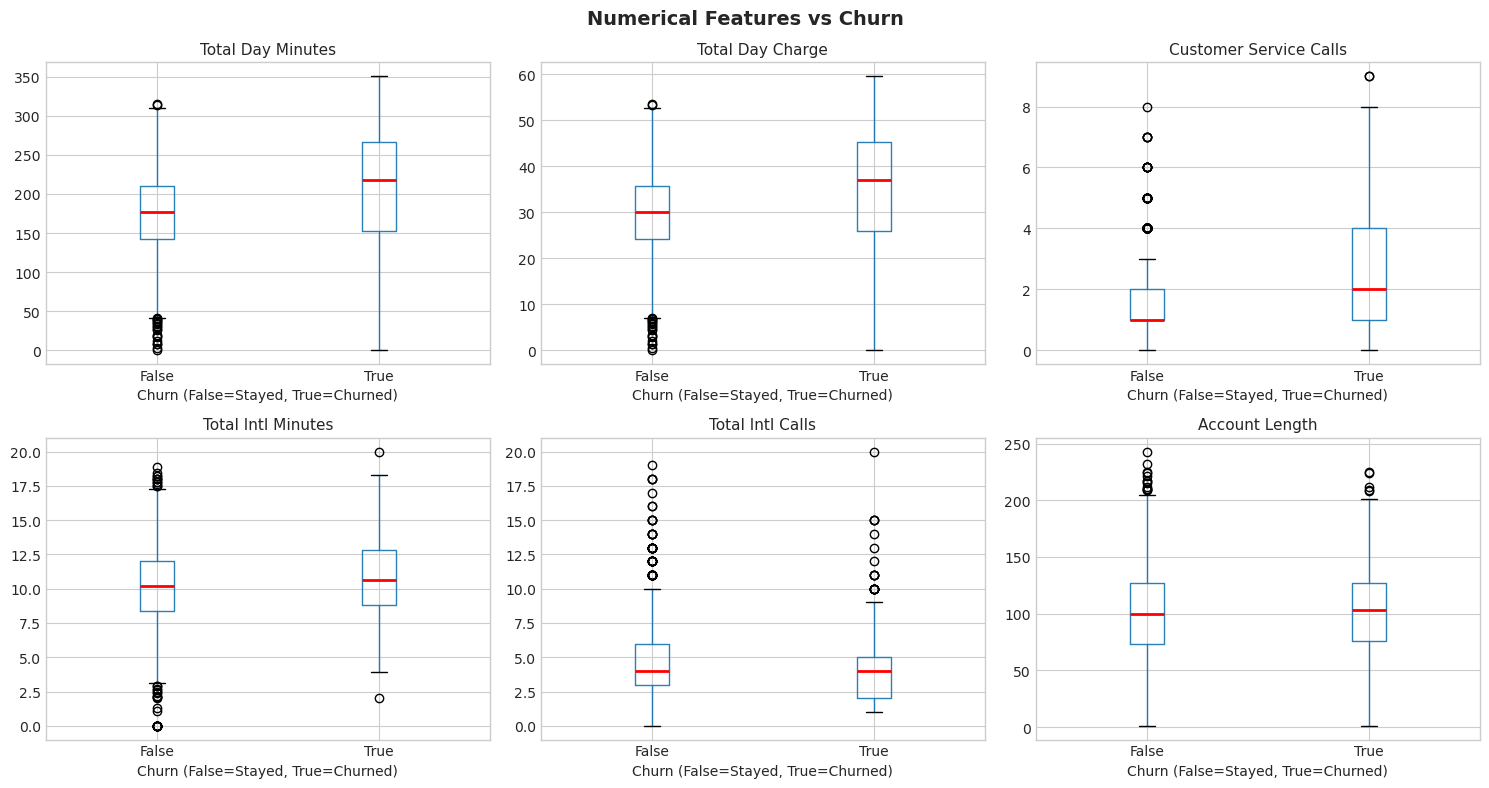

💡 Higher day minutes + more customer service calls → more churn!


In [9]:
# Numerical Feature vs Churn using Boxplot
num_cols = ['total day minutes', 'total day charge', 'customer service calls',
            'total intl minutes', 'total intl calls', 'account length']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='churn', ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.title(), fontsize=11)
    axes[i].set_xlabel('Churn (False=Stayed, True=Churned)')

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Higher day minutes + more customer service calls → more churn!")

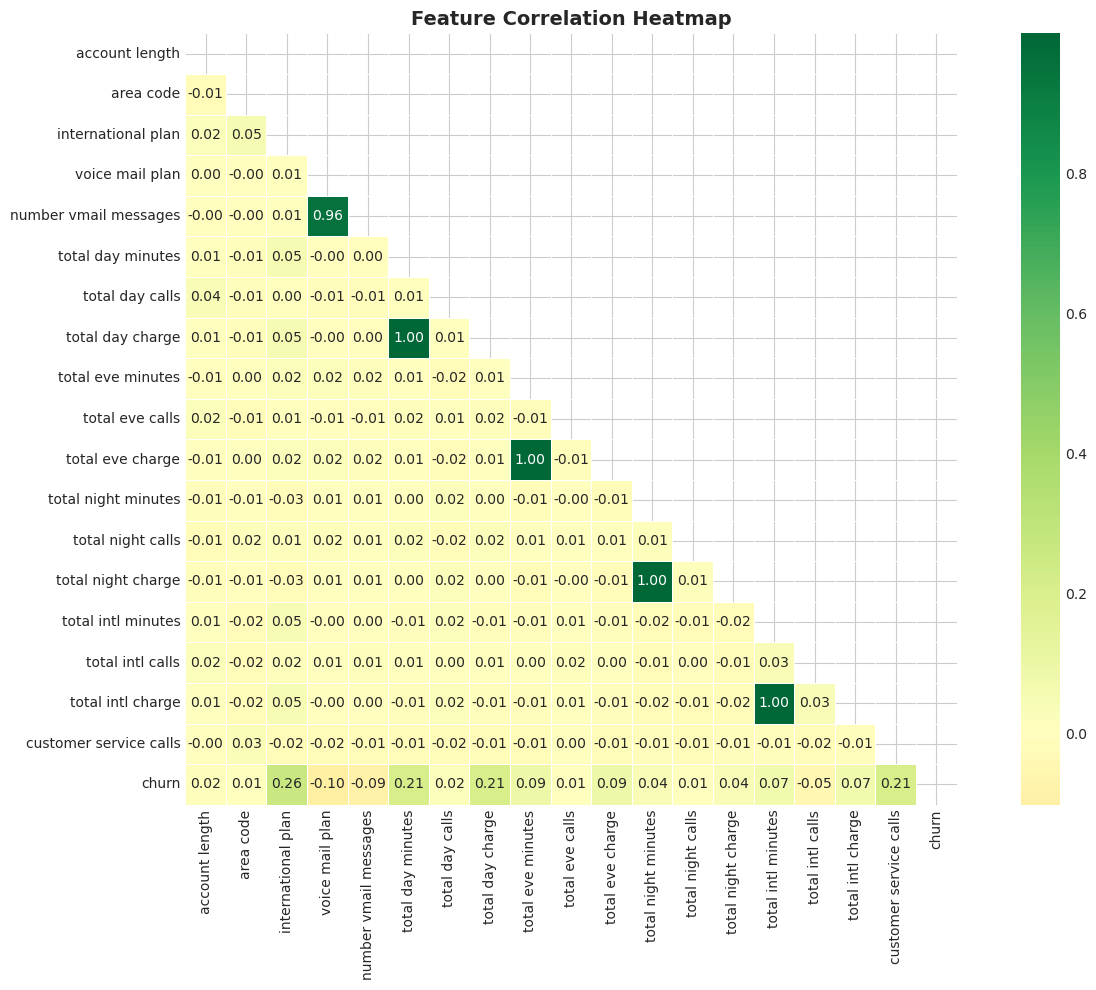

💡 Total day charge & total day minutes are perfectly correlated (multicollinearity!)


In [10]:
# Correaltion Heatmap
df_corr = df.copy()
df_corr['churn'] = df_corr['churn'].astype(int)
df_corr['international plan'] = (df_corr['international plan'] == 'yes').astype(int)
df_corr['voice mail plan'] = (df_corr['voice mail plan'] == 'yes').astype(int)

num_df = df_corr.select_dtypes(include=np.number)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Total day charge & total day minutes are perfectly correlated (multicollinearity!)")

In [11]:
# Data Preprocessing
data = df.copy()

# Step 1: Drop non-predictive columns
data.drop(columns=['phone number', 'state', 'area code'], inplace=True)
print("✅ Dropped: phone number, state, area code")

# Step 2: Encode target (True→1, False→0)
data['churn'] = data['churn'].astype(int)
print("✅ Target encoded: True→1, False→0")

# Step 3: Encode binary categoricals
data['international plan'] = (data['international plan'] == 'yes').astype(int)
data['voice mail plan'] = (data['voice mail plan'] == 'yes').astype(int)
print("✅ Binary encoded: international plan, voice mail plan")

# Step 4: Feature Engineering
data['day_charge_per_min'] = data['total day charge'] / (data['total day minutes'] + 0.01)
data['total_calls'] = (data['total day calls'] + data['total eve calls'] +
                       data['total night calls'] + data['total intl calls'])
data['total_spend'] = (data['total day charge'] + data['total eve charge'] +
                       data['total night charge'] + data['total intl charge'])
print("✅ New features: day_charge_per_min, total_calls, total_spend")

print(f"\nFinal shape: {data.shape}")
print(f"Missing values: {data.isnull().sum().sum()}")
data.head()

✅ Dropped: phone number, state, area code
✅ Target encoded: True→1, False→0
✅ Binary encoded: international plan, voice mail plan
✅ New features: day_charge_per_min, total_calls, total_spend

Final shape: (3333, 21)
Missing values: 0


,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,...,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,day_charge_per_min,total_calls,total_spend
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,...,91,11.01,10.0,3,2.70,1,0,0.170005,303,75.56
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,...,103,11.45,13.7,3,3.70,1,0,0.169977,332,59.24
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,...,104,7.32,12.2,5,3.29,0,0,0.170001,333,62.29
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,...,89,8.86,6.6,7,1.78,2,0,0.170001,255,66.80
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,...,121,8.41,10.1,3,2.73,3,0,0.169996,359,52.09


In [12]:
# Train-Test Split and Scaling
X = data.drop('churn', axis=1)
y = data['churn']

print(f"Features: {X.shape}  |  Target: {y.shape}")

# 80/20 split, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%")

# Scale (fit ONLY on train — no data leakage!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Scaling done! (fit on train only → prevents data leakage)")

Features: (3333, 20)  |  Target: (3333,)

✅ Train: 2666 rows  |  Test: 667 rows
Train churn rate: 14.5%  |  Test churn rate: 14.5%

✅ Scaling done! (fit on train only → prevents data leakage)


In [13]:
# Model Building and Evaluation
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Stayed', 'Churned']))
    print(f"ROC-AUC Score: {roc_auc_score(y_te, y_prob):.4f}")

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return model, roc_auc_score(y_te, y_prob), y_prob

print("✅ evaluate_model() ready!")

✅ evaluate_model() ready!



  Decision Tree
              precision    recall  f1-score   support

      Stayed       0.96      0.99      0.98       570
     Churned       0.96      0.78      0.86        97

    accuracy                           0.96       667
   macro avg       0.96      0.89      0.92       667
weighted avg       0.96      0.96      0.96       667

ROC-AUC Score: 0.8700


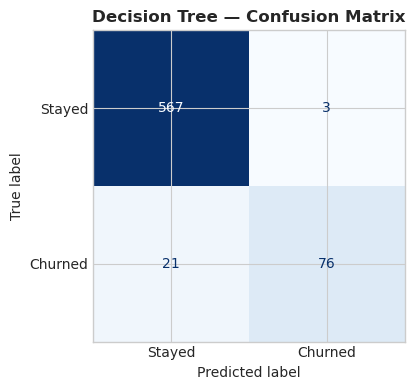

In [16]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                            random_state=42, class_weight='balanced')
dt_model, dt_auc, dt_prob = evaluate_model(
    'Decision Tree', dt,
    X_train, X_test, y_train, y_test
)


  Random Forest
              precision    recall  f1-score   support

      Stayed       0.96      1.00      0.98       570
     Churned       0.97      0.74      0.84        97

    accuracy                           0.96       667
   macro avg       0.97      0.87      0.91       667
weighted avg       0.96      0.96      0.96       667

ROC-AUC Score: 0.8980


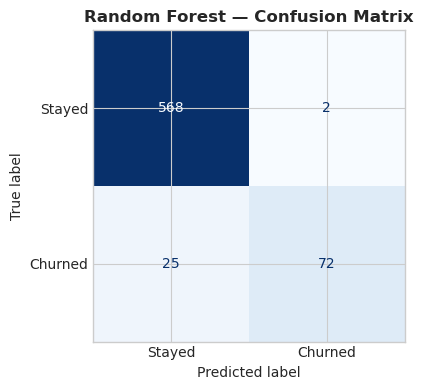

In [17]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                            random_state=42, class_weight='balanced', n_jobs=-1)
rf_model, rf_auc, rf_prob = evaluate_model(
    'Random Forest', rf,
    X_train, X_test, y_train, y_test
)


  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.95      0.76      0.84       570
     Churned       0.35      0.74      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667

ROC-AUC Score: 0.8149


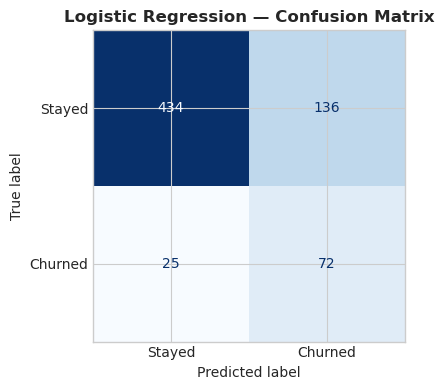

In [20]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model, lr_auc, lr_prob = evaluate_model(
    'Logistic Regression', lr,
    X_train_scaled, X_test_scaled, y_train, y_test
)

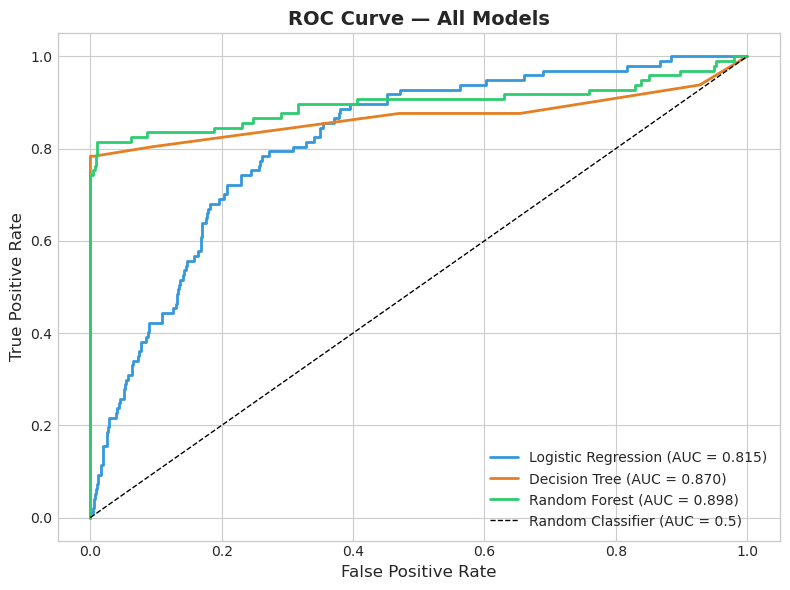

In [22]:
# Roc curve comparision
plt.figure(figsize=(8, 6))

models_info = [
    ('Logistic Regression', lr_prob, lr_auc),
    ('Decision Tree',       dt_prob, dt_auc),
    ('Random Forest',       rf_prob, rf_auc)
]
colors = ['#3498db', '#e67e22', '#2ecc71']

for (name, prob, auc), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [23]:
# Hypermeter Tuning
print("⏳ Running GridSearchCV... (takes ~1-2 mins)")

param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_split':[2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Recall:  {grid_search.best_score_:.4f}")


⏳ Running GridSearchCV... (takes ~1-2 mins)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
✅ Best CV Recall:  0.8446



  Tuned Random Forest
              precision    recall  f1-score   support

      Stayed       0.96      0.99      0.97       570
     Churned       0.93      0.76      0.84        97

    accuracy                           0.96       667
   macro avg       0.94      0.88      0.91       667
weighted avg       0.96      0.96      0.95       667

ROC-AUC Score: 0.8975


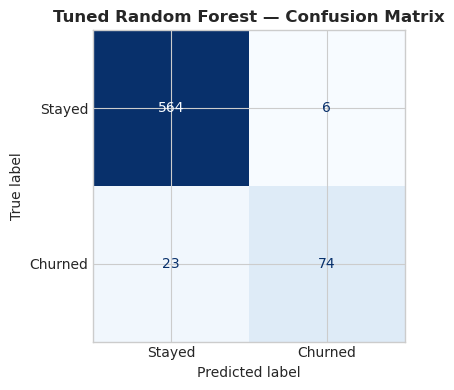

In [24]:
best_rf = grid_search.best_estimator_
best_rf_model, best_rf_auc, best_rf_prob = evaluate_model(
    'Tuned Random Forest', best_rf,
    X_train, X_test, y_train, y_test
)

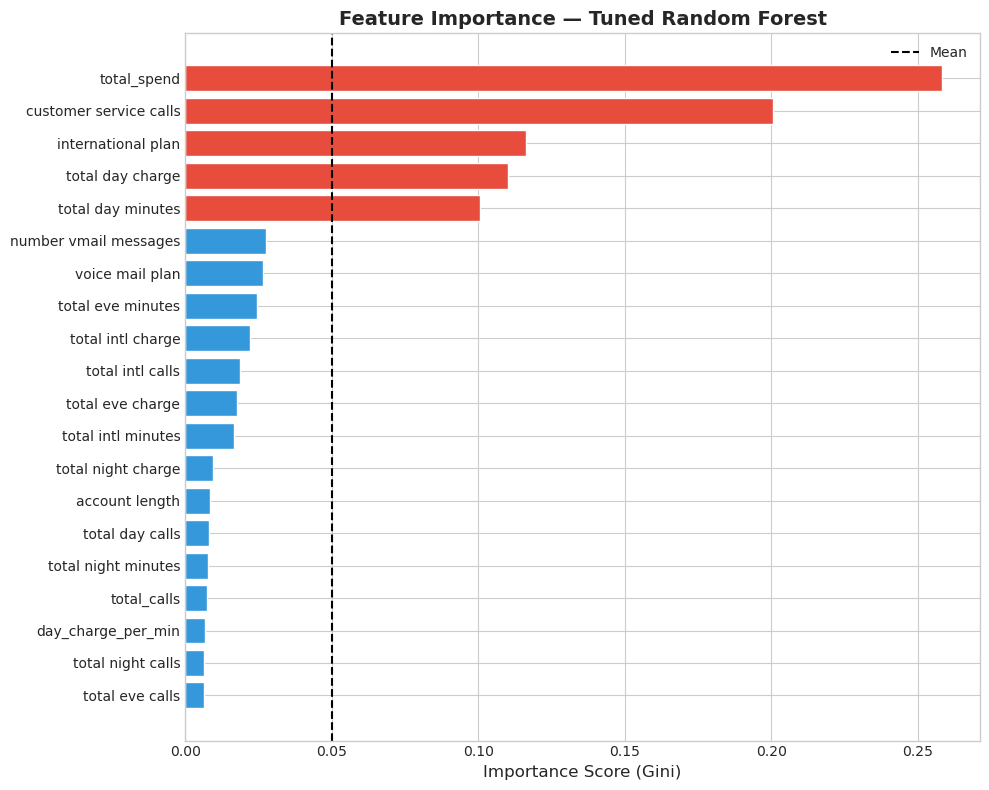


🔝 TOP 5 FEATURES:
               Feature  Importance
           total_spend    0.258226
customer service calls    0.200678
    international plan    0.116225
      total day charge    0.110139
     total day minutes    0.100724


In [25]:
# Feature Importance
feat_df = pd.DataFrame({
    'Feature':    X.columns.tolist(),
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if imp > feat_df['Importance'].quantile(0.75) else '#3498db'
          for imp in feat_df['Importance']]
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white')
plt.axvline(feat_df['Importance'].mean(), color='black', linestyle='--', label='Mean')
plt.xlabel('Importance Score (Gini)', fontsize=12)
plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n🔝 TOP 5 FEATURES:")
print(feat_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

In [26]:
# Final Comparision
print("="*65)
print("           FINAL MODEL COMPARISON SUMMARY")
print("="*65)
print(f"{'Model':<25} {'Accuracy':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-"*65)

all_models = [
    ('Logistic Regression',  lr_model,      X_test_scaled, lr_prob),
    ('Decision Tree',        dt_model,      X_test,        dt_prob),
    ('Random Forest',        rf_model,      X_test,        rf_prob),
    ('Tuned Random Forest',  best_rf_model, X_test,        best_rf_prob),
]

for name, model, X_te, prob in all_models:
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, prob)
    print(f"{name:<25} {acc:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f}")

print("="*65)
print("\n💡 Recall is most important — missing a churner costs more than a false alarm!")

           FINAL MODEL COMPARISON SUMMARY
Model                       Accuracy     Recall         F1        AUC
-----------------------------------------------------------------
Logistic Regression           0.7586     0.7423     0.4721     0.8149
Decision Tree                 0.9640     0.7835     0.8636     0.8700
Random Forest                 0.9595     0.7423     0.8421     0.8980
Tuned Random Forest           0.9565     0.7629     0.8362     0.8975

💡 Recall is most important — missing a churner costs more than a false alarm!


In [27]:
# Important Business Insights
print("""
============================================================
       📊 BUSINESS INSIGHTS FOR SYRIATEL
============================================================

1. CUSTOMER SERVICE CALLS 📞
   → 4+ calls = very high churn risk
   → Fix: Flag these customers for immediate retention call

2. INTERNATIONAL PLAN 🌍
   → ~42% of international plan holders churn
   → Fix: Revamp international pricing / offer better deals

3. HIGH DAY CHARGES 💸
   → Heavy daytime users get big bills → they leave
   → Fix: Offer unlimited day plans to heavy users

4. TOTAL SPEND 💰
   → High spenders are at higher churn risk
   → Fix: Loyalty rewards for top spenders

5. VOICE MAIL PLAN 📬
   → Voicemail holders churn LESS
   → Fix: Bundle voicemail as a free retention perk

============================================================
✅ Project Complete! Model is ready for deployment.
============================================================
""")


       📊 BUSINESS INSIGHTS FOR SYRIATEL

1. CUSTOMER SERVICE CALLS 📞
   → 4+ calls = very high churn risk
   → Fix: Flag these customers for immediate retention call

2. INTERNATIONAL PLAN 🌍
   → ~42% of international plan holders churn
   → Fix: Revamp international pricing / offer better deals

3. HIGH DAY CHARGES 💸
   → Heavy daytime users get big bills → they leave
   → Fix: Offer unlimited day plans to heavy users

4. TOTAL SPEND 💰
   → High spenders are at higher churn risk
   → Fix: Loyalty rewards for top spenders

5. VOICE MAIL PLAN 📬
   → Voicemail holders churn LESS
   → Fix: Bundle voicemail as a free retention perk

✅ Project Complete! Model is ready for deployment.



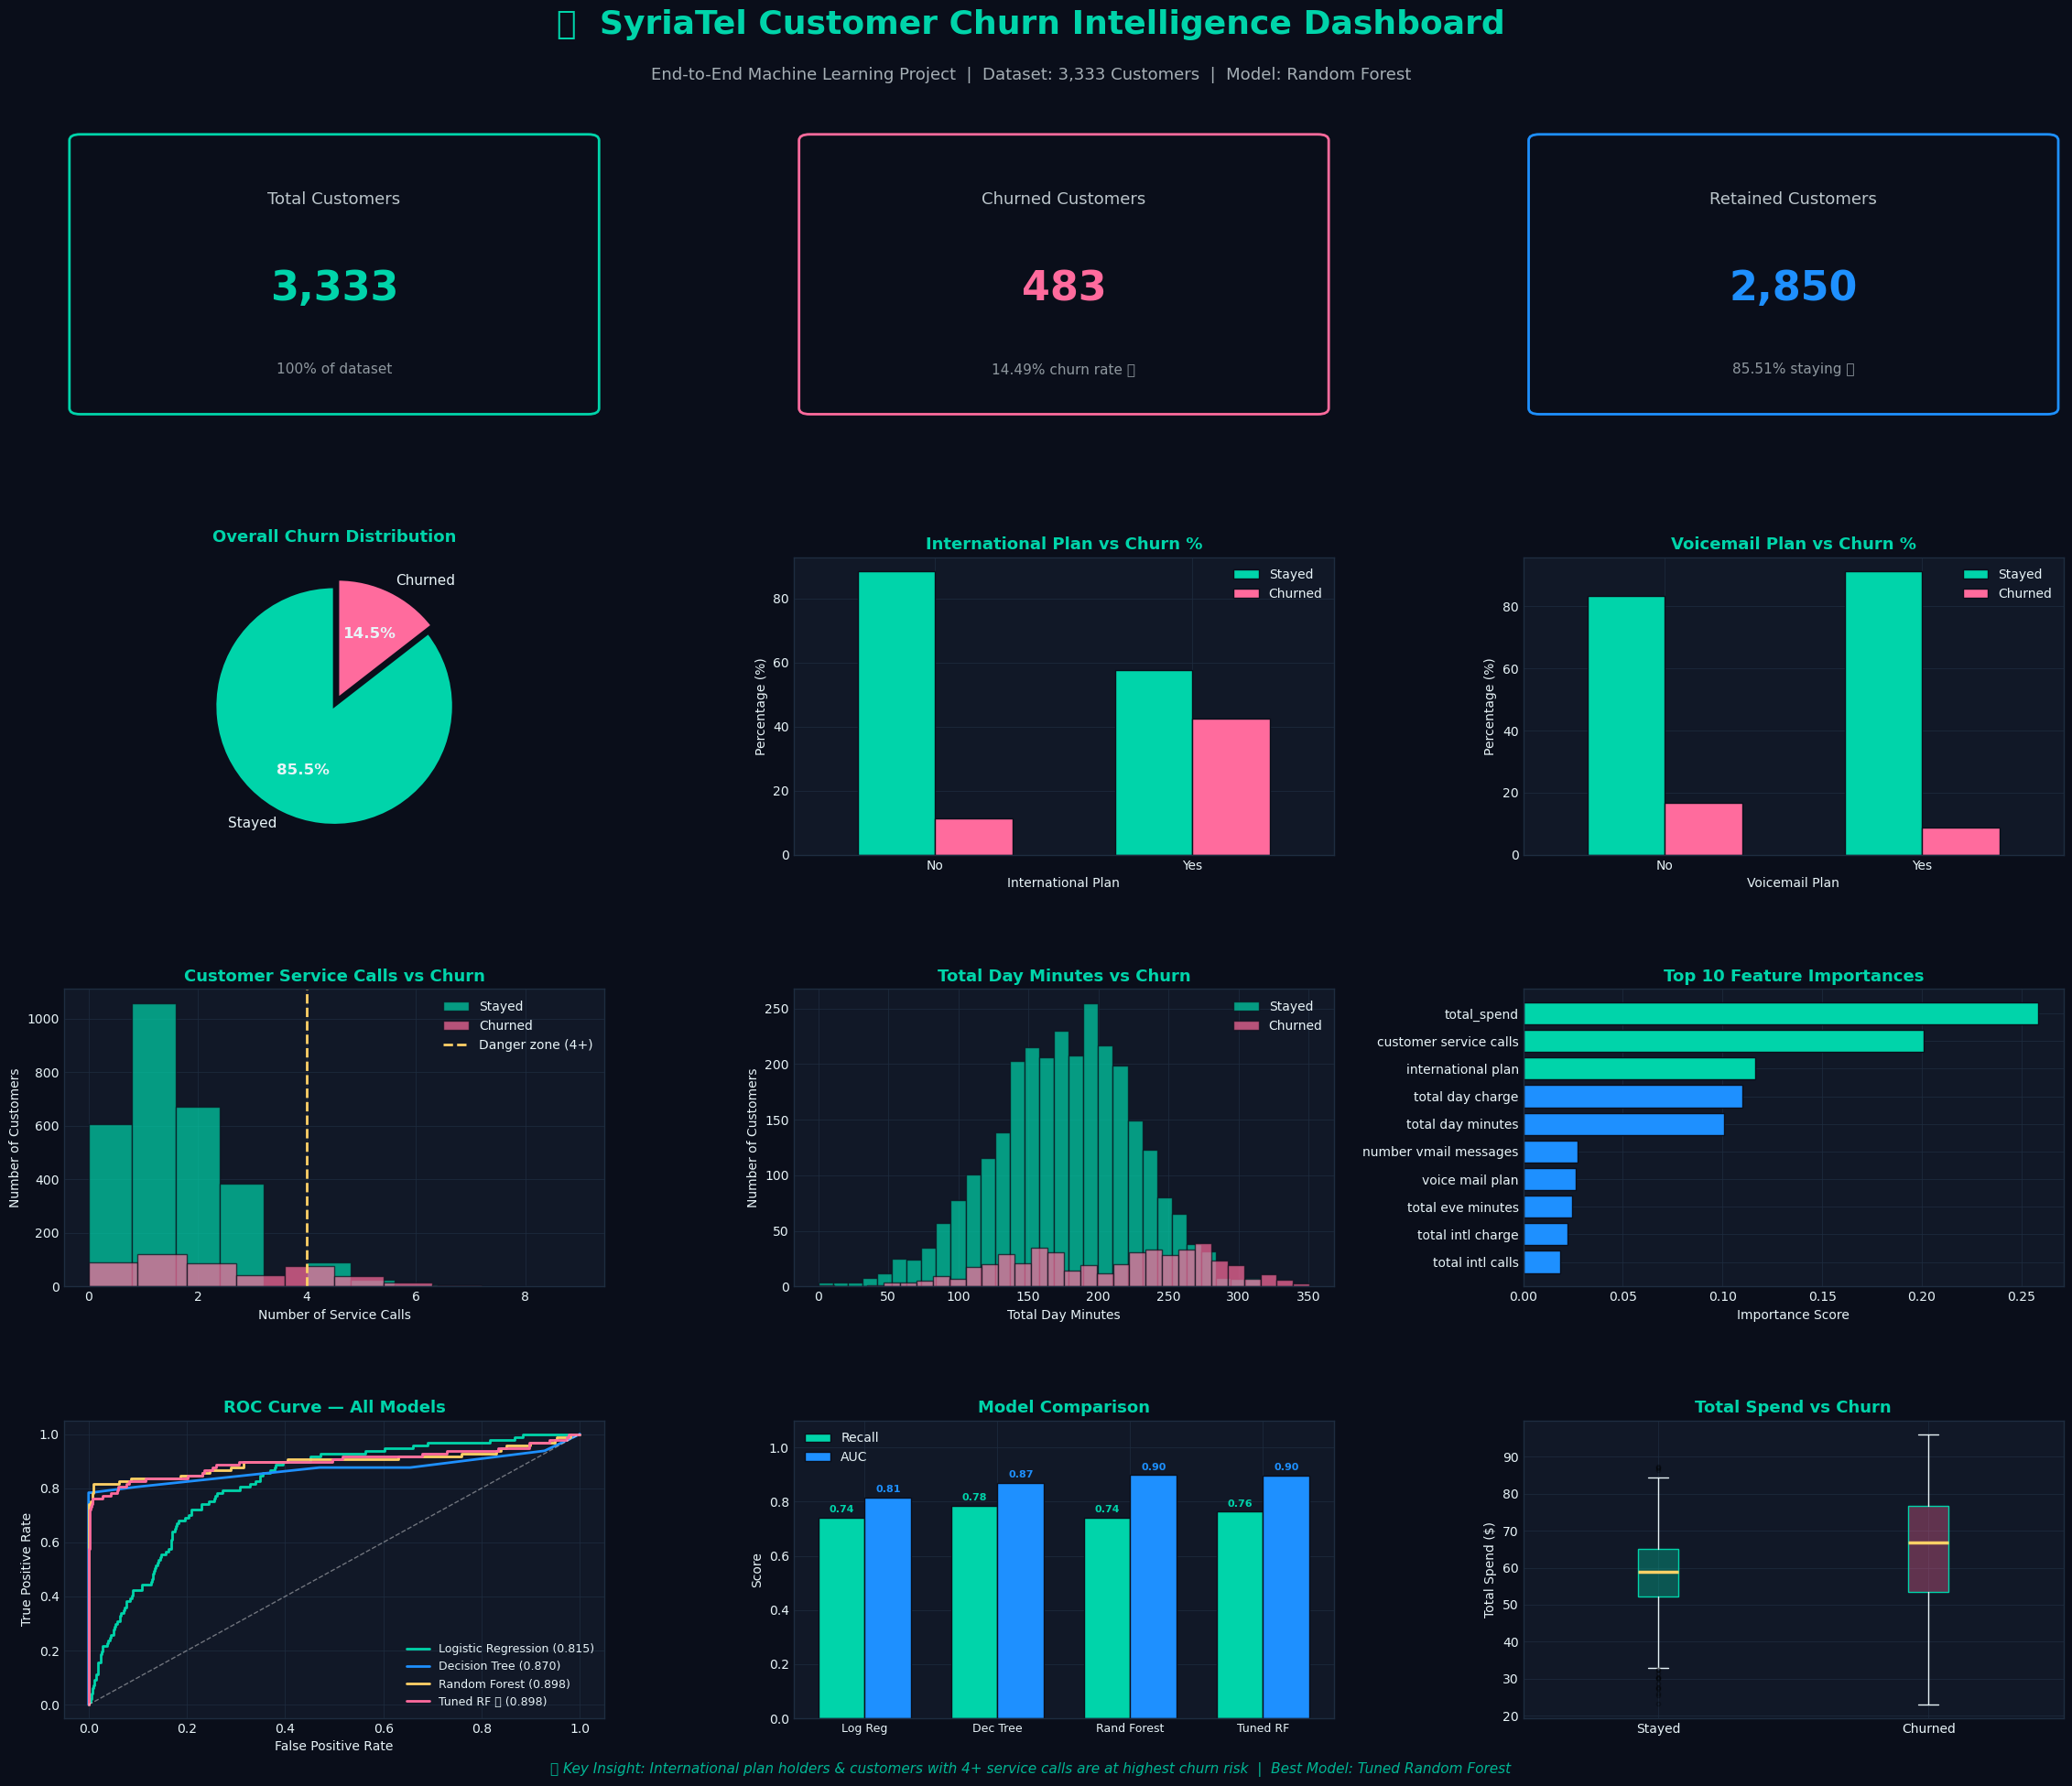

✅ Dashboard saved as 'syriatel_dashboard.png'!


In [28]:
# ============================================================
#       SYRIATEL CUSTOMER CHURN DASHBOARD
#       Theme: Dark Blue & Teal | 9 Charts
# ============================================================

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# ── Color Theme ──────────────────────────────────────────────
BG        = '#0a0e1a'   # main background
CARD      = '#111827'   # card background
TEAL      = '#00d4aa'   # primary teal
BLUE      = '#1e90ff'   # accent blue
PINK      = '#ff6b9d'   # churn highlight
YELLOW    = '#ffd166'   # warning color
WHITE     = '#e8f4f8'   # text
GRID      = '#1e2d40'   # gridlines
STAYED    = '#00d4aa'   # stayed = teal
CHURNED   = '#ff6b9d'   # churned = pink

plt.rcParams.update({
    'text.color':       WHITE,
    'axes.labelcolor':  WHITE,
    'xtick.color':      WHITE,
    'ytick.color':      WHITE,
    'axes.edgecolor':   GRID,
    'axes.facecolor':   CARD,
    'figure.facecolor': BG,
    'grid.color':       GRID,
    'grid.linewidth':   0.5,
})

# ── Canvas ───────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor(BG)

# Title
fig.text(0.5, 0.97,  '📱  SyriaTel Customer Churn Intelligence Dashboard',
         ha='center', fontsize=26, fontweight='bold', color=TEAL)
fig.text(0.5, 0.945, 'End-to-End Machine Learning Project  |  Dataset: 3,333 Customers  |  Model: Random Forest',
         ha='center', fontsize=13, color=WHITE, alpha=0.7)

# ── GridSpec: 4 rows ─────────────────────────────────────────
gs = gridspec.GridSpec(4, 3, figure=fig,
                       hspace=0.45, wspace=0.35,
                       top=0.92, bottom=0.05,
                       left=0.06, right=0.97)

# ═══════════════════════════════════════════════════════
# ROW 0 — KPI Metric Cards (3 cards)
# ═══════════════════════════════════════════════════════
kpis = [
    ('Total Customers',  '3,333',  '100% of dataset',       TEAL),
    ('Churned Customers','483',    '14.49% churn rate 🚨',  PINK),
    ('Retained Customers','2,850', '85.51% staying ✅',     BLUE),
]

for col, (title, value, sub, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(CARD)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # card border
    rect = FancyBboxPatch((0.03, 0.05), 0.94, 0.90,
                          boxstyle="round,pad=0.02",
                          linewidth=2, edgecolor=color,
                          facecolor=BG)
    ax.add_patch(rect)

    ax.text(0.5, 0.75, title, ha='center', va='center',
            fontsize=13, color=WHITE, alpha=0.8)
    ax.text(0.5, 0.45, value, ha='center', va='center',
            fontsize=32, fontweight='bold', color=color)
    ax.text(0.5, 0.18, sub, ha='center', va='center',
            fontsize=11, color=WHITE, alpha=0.6)

# ═══════════════════════════════════════════════════════
# ROW 1 — Chart 1: Churn Pie | Chart 2: Intl Plan | Chart 3: Voicemail
# ═══════════════════════════════════════════════════════

# Chart 1 — Churn Pie
ax1 = fig.add_subplot(gs[1, 0])
sizes  = [2850, 483]
colors_pie = [STAYED, CHURNED]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=['Stayed', 'Churned'],
    colors=colors_pie, autopct='%1.1f%%',
    startangle=90, explode=(0, 0.07),
    textprops={'color': WHITE, 'fontsize': 11},
    wedgeprops={'linewidth': 2, 'edgecolor': BG}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax1.set_title('Overall Churn Distribution', color=TEAL,
              fontsize=13, fontweight='bold', pad=12)

# Chart 2 — International Plan vs Churn
ax2 = fig.add_subplot(gs[1, 1])
intl_churn = df.groupby('international plan')['churn'].value_counts(normalize=True).unstack() * 100
intl_churn.plot(kind='bar', ax=ax2, color=[STAYED, CHURNED],
                edgecolor=BG, width=0.6)
ax2.set_title('International Plan vs Churn %', color=TEAL,
              fontsize=13, fontweight='bold')
ax2.set_xlabel('International Plan', color=WHITE)
ax2.set_ylabel('Percentage (%)', color=WHITE)
ax2.set_xticklabels(['No', 'Yes'], rotation=0)
ax2.legend(['Stayed', 'Churned'], facecolor=CARD, labelcolor=WHITE)
ax2.yaxis.grid(True, color=GRID)
ax2.set_axisbelow(True)

# Chart 3 — Voicemail Plan vs Churn
ax3 = fig.add_subplot(gs[1, 2])
vm_churn = df.groupby('voice mail plan')['churn'].value_counts(normalize=True).unstack() * 100
vm_churn.plot(kind='bar', ax=ax3, color=[STAYED, CHURNED],
              edgecolor=BG, width=0.6)
ax3.set_title('Voicemail Plan vs Churn %', color=TEAL,
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Voicemail Plan', color=WHITE)
ax3.set_ylabel('Percentage (%)', color=WHITE)
ax3.set_xticklabels(['No', 'Yes'], rotation=0)
ax3.legend(['Stayed', 'Churned'], facecolor=CARD, labelcolor=WHITE)
ax3.yaxis.grid(True, color=GRID)
ax3.set_axisbelow(True)

# ═══════════════════════════════════════════════════════
# ROW 2 — Chart 4: Service Calls | Chart 5: Day Minutes | Chart 6: Feature Importance
# ═══════════════════════════════════════════════════════

# Chart 4 — Customer Service Calls vs Churn
ax4 = fig.add_subplot(gs[2, 0])
stayed  = data[data['churn'] == 0]['customer service calls']
churned = data[data['churn'] == 1]['customer service calls']
ax4.hist(stayed,  bins=10, color=STAYED, alpha=0.7, label='Stayed',  edgecolor=BG)
ax4.hist(churned, bins=10, color=CHURNED, alpha=0.7, label='Churned', edgecolor=BG)
ax4.axvline(4, color=YELLOW, linestyle='--', linewidth=2, label='Danger zone (4+)')
ax4.set_title('Customer Service Calls vs Churn', color=TEAL,
              fontsize=13, fontweight='bold')
ax4.set_xlabel('Number of Service Calls', color=WHITE)
ax4.set_ylabel('Number of Customers', color=WHITE)
ax4.legend(facecolor=CARD, labelcolor=WHITE)
ax4.yaxis.grid(True, color=GRID)
ax4.set_axisbelow(True)

# Chart 5 — Total Day Minutes vs Churn
ax5 = fig.add_subplot(gs[2, 1])
stayed_min  = data[data['churn'] == 0]['total day minutes']
churned_min = data[data['churn'] == 1]['total day minutes']
ax5.hist(stayed_min,  bins=30, color=STAYED, alpha=0.7, label='Stayed',  edgecolor=BG)
ax5.hist(churned_min, bins=30, color=CHURNED, alpha=0.7, label='Churned', edgecolor=BG)
ax5.set_title('Total Day Minutes vs Churn', color=TEAL,
              fontsize=13, fontweight='bold')
ax5.set_xlabel('Total Day Minutes', color=WHITE)
ax5.set_ylabel('Number of Customers', color=WHITE)
ax5.legend(facecolor=CARD, labelcolor=WHITE)
ax5.yaxis.grid(True, color=GRID)
ax5.set_axisbelow(True)

# Chart 6 — Feature Importance (Top 10)
ax6 = fig.add_subplot(gs[2, 2])
feat_df_sorted = feat_df.sort_values('Importance', ascending=False).head(10)
bar_colors = [TEAL if i < 3 else BLUE for i in range(len(feat_df_sorted))]
bars = ax6.barh(feat_df_sorted['Feature'][::-1],
                feat_df_sorted['Importance'][::-1],
                color=bar_colors[::-1], edgecolor=BG)
ax6.set_title('Top 10 Feature Importances', color=TEAL,
              fontsize=13, fontweight='bold')
ax6.set_xlabel('Importance Score', color=WHITE)
ax6.xaxis.grid(True, color=GRID)
ax6.set_axisbelow(True)

# ═══════════════════════════════════════════════════════
# ROW 3 — Chart 7: ROC Curve | Chart 8: Model Comparison | Chart 9: Total Spend
# ═══════════════════════════════════════════════════════

# Chart 7 — ROC Curve
ax7 = fig.add_subplot(gs[3, 0])
roc_colors = [TEAL, BLUE, YELLOW, PINK]
roc_models = [
    ('Logistic Regression', lr_prob,      lr_auc),
    ('Decision Tree',       dt_prob,      dt_auc),
    ('Random Forest',       rf_prob,      rf_auc),
    ('Tuned RF ⭐',          best_rf_prob, best_rf_auc),
]
for (name, prob, auc), color in zip(roc_models, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax7.plot(fpr, tpr, color=color, lw=2, label=f'{name} ({auc:.3f})')
ax7.plot([0,1],[0,1], 'w--', lw=1, alpha=0.4)
ax7.set_title('ROC Curve — All Models', color=TEAL,
              fontsize=13, fontweight='bold')
ax7.set_xlabel('False Positive Rate', color=WHITE)
ax7.set_ylabel('True Positive Rate', color=WHITE)
ax7.legend(facecolor=CARD, labelcolor=WHITE, fontsize=9)
ax7.yaxis.grid(True, color=GRID)
ax7.xaxis.grid(True, color=GRID)
ax7.set_axisbelow(True)

# Chart 8 — Model Comparison Bar Chart
ax8 = fig.add_subplot(gs[3, 1])
model_names  = ['Log Reg', 'Dec Tree', 'Rand Forest', 'Tuned RF']
recall_scores = []
auc_scores    = []

all_models_eval = [
    (lr_model,      X_test_scaled, lr_prob),
    (dt_model,      X_test,        dt_prob),
    (rf_model,      X_test,        rf_prob),
    (best_rf_model, X_test,        best_rf_prob),
]
for model, X_te, prob in all_models_eval:
    y_pred = model.predict(X_te)
    recall_scores.append(recall_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, prob))

x = np.arange(len(model_names))
width = 0.35
bars1 = ax8.bar(x - width/2, recall_scores, width,
                label='Recall', color=TEAL,   edgecolor=BG)
bars2 = ax8.bar(x + width/2, auc_scores,    width,
                label='AUC',    color=BLUE,   edgecolor=BG)

ax8.set_title('Model Comparison', color=TEAL,
              fontsize=13, fontweight='bold')
ax8.set_ylabel('Score', color=WHITE)
ax8.set_xticks(x)
ax8.set_xticklabels(model_names, fontsize=9)
ax8.set_ylim(0, 1.1)
ax8.legend(facecolor=CARD, labelcolor=WHITE)
ax8.yaxis.grid(True, color=GRID)
ax8.set_axisbelow(True)

# value labels on bars
for bar in bars1:
    ax8.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=8, color=TEAL, fontweight='bold')
for bar in bars2:
    ax8.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=8, color=BLUE, fontweight='bold')

# Chart 9 — Total Spend vs Churn (Boxplot)
ax9 = fig.add_subplot(gs[3, 2])
stayed_spend  = data[data['churn'] == 0]['total_spend']
churned_spend = data[data['churn'] == 1]['total_spend']
bp = ax9.boxplot([stayed_spend, churned_spend],
                 patch_artist=True,
                 labels=['Stayed', 'Churned'],
                 boxprops=dict(facecolor=CARD, color=TEAL),
                 medianprops=dict(color=YELLOW, linewidth=2.5),
                 whiskerprops=dict(color=WHITE),
                 capprops=dict(color=WHITE),
                 flierprops=dict(marker='o', color=PINK, alpha=0.3, markersize=3))
bp['boxes'][0].set_facecolor(STAYED + '55')
bp['boxes'][1].set_facecolor(CHURNED + '55')
ax9.set_title('Total Spend vs Churn', color=TEAL,
              fontsize=13, fontweight='bold')
ax9.set_ylabel('Total Spend ($)', color=WHITE)
ax9.yaxis.grid(True, color=GRID)
ax9.set_axisbelow(True)

# ── Footer ───────────────────────────────────────────────────
fig.text(0.5, 0.02,
         '💡 Key Insight: International plan holders & customers with 4+ service calls are at highest churn risk  |  Best Model: Tuned Random Forest',
         ha='center', fontsize=11, color=TEAL, alpha=0.85, style='italic')

plt.savefig('syriatel_dashboard.png', dpi=180, bbox_inches='tight',
            facecolor=BG)
plt.show()
print("✅ Dashboard saved as 'syriatel_dashboard.png'!")